# Finetuning for Sentiment Classification

In [1]:
%pip install matplotlib numpy safetensors tiktoken torch pandas requests tqdm

Note: you may need to restart the kernel to use updated packages.


In [2]:
from importlib.metadata import version

print("matplotlib version:", version("matplotlib"))
print("numpy version:", version("numpy"))
print("pandas version:", version("pandas"))
print("requests version:", version("requests"))
print("safetensors version:", version("safetensors"))
print("tiktoken version:", version("tiktoken"))
print("torch version:", version("torch"))
print("tqdm version:", version("tqdm"))

matplotlib version: 3.11.1
numpy version: 2.5.1
pandas version: 3.0.5
requests version: 2.34.2
safetensors version: 0.8.0
tiktoken version: 0.13.0
torch version: 2.13.0
tqdm version: 4.69.1


### 1. Dataset Preparation

Download and extract the Sentiment Labelled Sentences data from the [UCI archive](https://archive.ics.uci.edu/dataset/331/sentiment+labelled+sentences).

In [3]:
import zipfile
import requests
import os
from pathlib import Path

url = "https://archive.ics.uci.edu/static/public/331/sentiment+labelled+sentences.zip"
zip_path = "sentiment+labelled+sentences.zip"
extracted_path = "sentiment labelled sentences"
amazon_cells_labelled_file_path = Path(extracted_path) / "amazon_cells_labelled.txt"
imdb_labelled_file_path = Path(extracted_path) / "imdb_labelled.txt"
yelp_labelled_file_path = Path(extracted_path) / "yelp_labelled.txt"


def download_and_unzip_sentiment_data(url, zip_path, extracted_path):
    if amazon_cells_labelled_file_path.exists() or imdb_labelled_file_path.exists() or yelp_labelled_file_path.exists():
        print(f"Data already exists. Skipping download and extraction.")
        return

    # Downloading the file
    response = requests.get(url, stream=True, timeout=60)
    response.raise_for_status()
    with open(zip_path, "wb") as out_file:
        for chunk in response.iter_content(chunk_size=8192):
            if chunk:
                out_file.write(chunk)
    
    # Unzipping the file
    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        zip_ref.extractall()

    print(f"Sentiment data downloaded and saved")

try:
    download_and_unzip_sentiment_data(url, zip_path, extracted_path)
except (requests.exceptions.RequestException, TimeoutError) as e:
    print(f"File download failed: {e}.")

Data already exists. Skipping download and extraction.


Load the data into Pandas

In [4]:
import pandas as pd
import csv
import io

amazon_df = pd.read_csv(amazon_cells_labelled_file_path, sep="\t", header=None, names=["Text", "Label"])
yelp_df = pd.read_csv(yelp_labelled_file_path, sep="\t", header=None, names=["Text", "Label"])

raw = open(imdb_labelled_file_path, "rb").read()
text = raw.decode("utf-8")
c1 = {b: bytes([b]).decode("cp1252", "replace") for b in range(0x80, 0xA0)}
text = text.translate(c1)
imdb_df = pd.read_csv(
    io.StringIO(text),
    sep="\t",
    header=None,
    names=["Text", "Label"],
    quoting=csv.QUOTE_NONE,
)


In [5]:
from collections import Counter

src = text.splitlines()          # the normalized text from before
print("source lines:", len(src), "parsed rows:", len(imdb_df))
print("tab counts:", Counter(l.count("\t") for l in src))
for i in imdb_df.index[imdb_df["Label"].isna()]:
    print(i, repr(src[i]))

source lines: 1000 parsed rows: 1000
tab counts: Counter({1: 1000})


In [6]:
print("Amazon Data")
print(amazon_df[0:10])
print(amazon_df["Label"].value_counts())

Amazon Data
                                                Text  Label
0  So there is no way for me to plug it in here i...      0
1                        Good case, Excellent value.      1
2                             Great for the jawbone.      1
3  Tied to charger for conversations lasting more...      0
4                                  The mic is great.      1
5  I have to jiggle the plug to get it to line up...      0
6  If you have several dozen or several hundred c...      0
7        If you are Razr owner...you must have this!      1
8                Needless to say, I wasted my money.      0
9                   What a waste of money and time!.      0
Label
0    500
1    500
Name: count, dtype: int64


In [7]:
print("IMDB Data")
print(imdb_df[0:10])
print(imdb_df["Label"].value_counts())

IMDB Data
                                                Text  Label
0  A very, very, very slow-moving, aimless movie ...      0
1  Not sure who was more lost - the flat characte...      0
2  Attempting artiness with black & white and cle...      0
3       Very little music or anything to speak of.        0
4  The best scene in the movie was when Gerardo i...      1
5  The rest of the movie lacks art, charm, meanin...      0
6                                Wasted two hours.        0
7  Saw the movie today and thought it was a good ...      1
8                               A bit predictable.        0
9  Loved the casting of Jimmy Buffet as the scien...      1
Label
0    500
1    500
Name: count, dtype: int64


In [8]:
print("Yelp Data")
print(yelp_df[0:10])
print(yelp_df["Label"].value_counts())

Yelp Data
                                                Text  Label
0                           Wow... Loved this place.      1
1                                 Crust is not good.      0
2          Not tasty and the texture was just nasty.      0
3  Stopped by during the late May bank holiday of...      1
4  The selection on the menu was great and so wer...      1
5     Now I am getting angry and I want my damn pho.      0
6              Honeslty it didn't taste THAT fresh.)      0
7  The potatoes were like rubber and you could te...      0
8                          The fries were great too.      1
9                                     A great touch.      1
Label
1    500
0    500
Name: count, dtype: int64


`ignore_index=True` renumbers `0..n-1` — without it you get repeated index values from each source to avoid any issues later with `.loc` and joins.

In [9]:
df = pd.concat([imdb_df, yelp_df, amazon_df], ignore_index=True)
print(df["Label"].value_counts())

Label
0    1500
1    1500
Name: count, dtype: int64


The dataset is conveniently balanced so we can move straight into splitting the dataset for training, validation and test.

In [10]:
def random_split(df, train_frac, validation_frac):
    # Shuffle the entire DataFrame
    df = df.sample(frac=1, random_state=123).reset_index(drop=True)

    # Calculate split indices
    train_end = int(len(df) * train_frac)
    validation_end = train_end + int(len(df) * validation_frac)

    # Split the DataFrame
    train_df = df[:train_end]
    validation_df = df[train_end:validation_end]
    test_df = df[validation_end:]

    return train_df, validation_df, test_df

train_df, validation_df, test_df = random_split(df, 0.7, 0.1)
# Test size is implied to be 0.2 as the remainder

training_file = Path(extracted_path) / "train.csv"
validation_file = Path(extracted_path) / "validation.csv"
test_file = Path(extracted_path)/"test.csv"

train_df.to_csv(training_file, index=None)
validation_df.to_csv(validation_file, index=None)
test_df.to_csv(test_file, index=None)

print(train_df["Label"].value_counts())
print(validation_df["Label"].value_counts())
print(test_df["Label"].value_counts())

Label
0    1055
1    1045
Name: count, dtype: int64
Label
0    156
1    144
Name: count, dtype: int64
Label
1    311
0    289
Name: count, dtype: int64


### 2. Data Loading

Not all examples are of the same length. Hence, we need to add padding to equalise the length.

For that, we use `<|endoftext|>` as a padding token.

In [11]:
import tiktoken

tokenizer = tiktoken.get_encoding("gpt2")
print(tokenizer.encode("<|endoftext|>", allowed_special={"<|endoftext|>"}))

[50256]


In [12]:
import torch
from torch.utils.data import Dataset

class SentimentDataset(Dataset):
    def __init__(self, csv_file, tokenizer, max_length=None, pad_token_id=50256):
        self.data = pd.read_csv(csv_file)

        # Pre-tokenize texts
        self.encoded_texts = [
            tokenizer.encode(text) for text in self.data["Text"]
        ]

        if max_length is None:
            self.max_length = self._longest_encoded_length()
        else:
            self.max_length = max_length
            # Truncate sequences if they are longer than max_length
            self.encoded_texts = [
                encoded_text[:self.max_length]
                for encoded_text in self.encoded_texts
            ]

        # Pad sequences to the longest sequence
        self.encoded_texts = [
            encoded_text + [pad_token_id] * (self.max_length - len(encoded_text))
            for encoded_text in self.encoded_texts
        ]

    def __getitem__(self, index):
        encoded = self.encoded_texts[index]
        label = self.data.iloc[index]["Label"]
        return (
            torch.tensor(encoded, dtype=torch.long),
            torch.tensor(label, dtype=torch.long)
        )

    def __len__(self):
        return len(self.data)

    def _longest_encoded_length(self):
        return max(len(encoded_text) for encoded_text in self.encoded_texts)

In [13]:
training_ds = SentimentDataset(
    csv_file=training_file,
    max_length=None,
    tokenizer=tokenizer
)

print("Training sample max length: ", training_ds.max_length)

Training sample max length:  103


In [14]:
validation_ds = SentimentDataset(
    csv_file=validation_file,
    max_length=None,
    tokenizer=tokenizer
)
print("Validation sample max length: ", validation_ds.max_length)

test_ds = SentimentDataset(
    csv_file=test_file,
    max_length=None,
    tokenizer=tokenizer
)
print("Test sample max length: ", test_ds.max_length)

Validation sample max length:  53
Test sample max length:  83


Instantiate the data loaders

In [15]:
from torch.utils.data import DataLoader

num_workers = 0
batch_size = 8

torch.manual_seed(123)

training_loader = DataLoader(
    dataset=training_ds,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers,
    drop_last=True,
)

validation_loader = DataLoader(
    dataset=validation_ds,
    batch_size=batch_size,
    num_workers=num_workers,
    drop_last=False,
)

test_loader = DataLoader(
    dataset=test_ds,
    batch_size=batch_size,
    num_workers=num_workers,
    drop_last=False,
)

In [16]:
print("Train loader:")
for input_batch, target_batch in training_loader:
    pass

print("Input batch dimensions:", input_batch.shape)
print("Label batch dimensions", target_batch.shape)

Train loader:
Input batch dimensions: torch.Size([8, 103])
Label batch dimensions torch.Size([8])


In [17]:
print(f"{len(training_loader)} training batches")
print(f"{len(validation_loader)} validation batches")
print(f"{len(test_loader)} test batches")

262 training batches
38 validation batches
75 test batches


### 3. Initializing a model with pretrained weights

In [18]:
CHOOSE_MODEL = "gpt2-small-124M"
TUNE_TRF_BLOCKS = -1 # amount of transformer blocks to finetune
PLOT_FOR_COMPARISSON = False

model_config = {
    "vocab_size": 50257,     # Vocabulary size
    "context_length": 1024,  # Context length
    "drop_rate": 0.0,        # Dropout rate
    "qkv_bias": True         # Query-key-value bias
}

MODEL_UPDATES = {
    "gpt2-small-124M": {"emb_dim": 768, "n_layers": 12, "n_heads": 12},
    "gpt2-medium-355M": {"emb_dim": 1024, "n_layers": 24, "n_heads": 16},
    "gpt2-large-774M": {"emb_dim": 1280, "n_layers": 36, "n_heads": 20},
    "gpt2-xl-1558M)": {"emb_dim": 1600, "n_layers": 48, "n_heads": 25},
}

model_config.update(MODEL_UPDATES[CHOOSE_MODEL])

assert training_ds.max_length <= model_config["context_length"], (
    f"Dataset length {training_ds.max_length} exceeds model's context "
    f"length {model_config['context_length']}. Reinitialize data sets with "
    f"`max_length={model_config['context_length']}`"
)

In [19]:
import os
import requests
from safetensors.torch import load_file

URL_DIR = {
  "gpt2-small-124M": "gpt2",         # works ok
  "gpt2-medium-355M": "gpt2-medium", # this file seems to have issues via `generate`
  "gpt2-large-774M": "gpt2-large",   # works ok
  "gpt2-xl-1558M": "gpt2-xl"         # works ok
}

url = f"https://huggingface.co/openai-community/{URL_DIR[CHOOSE_MODEL]}/resolve/main/model.safetensors"
output_file = f"model-{URL_DIR[CHOOSE_MODEL]}.safetensors"

# Download file
if not os.path.exists(output_file):
    response = requests.get(url, timeout=30)
    response.raise_for_status()
    with open(output_file, "wb") as f:
        f.write(response.content)

# Load file
state_dict = load_file(output_file)

In [20]:
def assign(left, right):
    if left.shape != right.shape:
        raise ValueError(f"Shape mismatch. Left: {left.shape}, Right: {right.shape}")
    return torch.nn.Parameter(right.detach())

In [21]:
def load_weights_into_gpt(gpt, params):
    gpt.pos_emb.weight = assign(gpt.pos_emb.weight, params["wpe.weight"])
    gpt.tok_emb.weight = assign(gpt.tok_emb.weight, params["wte.weight"])

    for b in range(len(gpt.trf_blocks)):
        q_w, k_w, v_w = torch.chunk(
            params[f"h.{b}.attn.c_attn.weight"], 3, axis=-1)
        gpt.trf_blocks[b].att.W_query.weight = assign(
            gpt.trf_blocks[b].att.W_query.weight, q_w.T)
        gpt.trf_blocks[b].att.W_key.weight = assign(
            gpt.trf_blocks[b].att.W_key.weight, k_w.T)
        gpt.trf_blocks[b].att.W_value.weight = assign(
            gpt.trf_blocks[b].att.W_value.weight, v_w.T)

        q_b, k_b, v_b = torch.chunk(
            params[f"h.{b}.attn.c_attn.bias"], 3, axis=-1)
        gpt.trf_blocks[b].att.W_query.bias = assign(
            gpt.trf_blocks[b].att.W_query.bias, q_b)
        gpt.trf_blocks[b].att.W_key.bias = assign(
            gpt.trf_blocks[b].att.W_key.bias, k_b)
        gpt.trf_blocks[b].att.W_value.bias = assign(
            gpt.trf_blocks[b].att.W_value.bias, v_b)

        gpt.trf_blocks[b].att.out_proj.weight = assign(
            gpt.trf_blocks[b].att.out_proj.weight,
            params[f"h.{b}.attn.c_proj.weight"].T)
        gpt.trf_blocks[b].att.out_proj.bias = assign(
            gpt.trf_blocks[b].att.out_proj.bias,
            params[f"h.{b}.attn.c_proj.bias"])

        gpt.trf_blocks[b].ff.layers[0].weight = assign(
            gpt.trf_blocks[b].ff.layers[0].weight,
            params[f"h.{b}.mlp.c_fc.weight"].T)
        gpt.trf_blocks[b].ff.layers[0].bias = assign(
            gpt.trf_blocks[b].ff.layers[0].bias,
            params[f"h.{b}.mlp.c_fc.bias"])
        gpt.trf_blocks[b].ff.layers[2].weight = assign(
            gpt.trf_blocks[b].ff.layers[2].weight,
            params[f"h.{b}.mlp.c_proj.weight"].T)
        gpt.trf_blocks[b].ff.layers[2].bias = assign(
            gpt.trf_blocks[b].ff.layers[2].bias,
            params[f"h.{b}.mlp.c_proj.bias"])

        gpt.trf_blocks[b].norm1.scale = assign(
            gpt.trf_blocks[b].norm1.scale,
            params[f"h.{b}.ln_1.weight"])
        gpt.trf_blocks[b].norm1.shift = assign(
            gpt.trf_blocks[b].norm1.shift,
            params[f"h.{b}.ln_1.bias"])
        gpt.trf_blocks[b].norm2.scale = assign(
            gpt.trf_blocks[b].norm2.scale,
            params[f"h.{b}.ln_2.weight"])
        gpt.trf_blocks[b].norm2.shift = assign(
            gpt.trf_blocks[b].norm2.shift,
            params[f"h.{b}.ln_2.bias"])

    gpt.final_norm.scale = assign(gpt.final_norm.scale, params["ln_f.weight"])
    gpt.final_norm.shift = assign(gpt.final_norm.shift, params["ln_f.bias"])
    gpt.out_head.weight = assign(gpt.out_head.weight, params["wte.weight"])

In [22]:
import torch
from llmfs_lib import GPTModel

model = GPTModel(model_config)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
load_weights_into_gpt(model, state_dict)

In [23]:
print(model)

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(1024, 768)
  (drop_emb): Dropout(p=0.0, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=True)
        (W_key): Linear(in_features=768, out_features=768, bias=True)
        (W_value): Linear(in_features=768, out_features=768, bias=True)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.0, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_resid): Dropout(p=0.0, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768,

Make sure that the model was loaded correctly and see whether it generates coherent text.

In [24]:
from llmfs_lib import (
    generate_text_simple,
    text_to_token_ids,
    token_ids_to_text
)

text_1 = "Every effort moves you"

token_ids = generate_text_simple(
    model=model,
    idx=text_to_token_ids(text_1, tokenizer),
    max_new_tokens=25,
    context_size=model_config["context_length"]
)

print(token_ids_to_text(token_ids, tokenizer))

Every effort moves you forward.

The first step is to understand the importance of your work.

The second step is to understand the


See what the model is capable of before we fine tune it.

In [25]:
text_2 = (
    "Is the sentiment in the following text positive? Answer with 'yes' or 'no':"
    " 'Let us make this a great effort'."
)

token_ids = generate_text_simple(
    model=model,
    idx=text_to_token_ids(text_2, tokenizer),
    max_new_tokens=23,
    context_size=model_config["context_length"]
)

print(token_ids_to_text(token_ids, tokenizer))

Is the sentiment in the following text positive? Answer with 'yes' or 'no': 'Let us make this a great effort'.

The following text is a translation of the original text of the book, which was published in the English language


Not very convincing... We definitely have to finetune this model.

### 4. Adding a classification head

We will modify the pretrained LLM by replacing the output layer `(model.out_head)` to make it ready for classification finetuning.

In the pretrained model the output layer maps its inputs to 50,257 dimensions (the size of the tokenizer vocabulary).

Our Sentiment finetuned model will have to map to 2 dimensions to produce binary classification outputs (predicting 2 classes, "positive" and "negative" sentiment).

Note: Theoretically this could be achieved with a single output dimension but that would require us to change the logic on architecture of how we process the logits. It's better to keep our model architecture generic so we can easily adapt it to higher dimensional classification tasks in the future.

In [26]:
inputs = tokenizer.encode("Do you have time")
inputs = torch.tensor(inputs).unsqueeze(0)
print("Inputs:", inputs)
print("Inputs dimensions:", inputs.shape) # shape: (batch_size, num_tokens)

with torch.no_grad():
    outputs = model(inputs)

print("Outputs:\n", outputs)
print("Outputs dimensions:", outputs.shape) # shape: (batch_size, num_tokens, num_classes)

Inputs: tensor([[5211,  345,  423,  640]])
Inputs dimensions: torch.Size([1, 4])
Outputs:
 tensor([[[ -33.6588,  -33.3694,  -36.8126,  ...,  -42.0255,  -41.7656,
           -34.4997],
         [-143.6805, -144.6794, -148.9713,  ..., -153.4315, -153.5064,
          -146.7251],
         [-107.3298, -108.1823, -113.0994,  ..., -109.9246, -111.5400,
          -108.6097],
         [ -79.5568,  -79.3292,  -84.7638,  ...,  -89.4910,  -89.7658,
           -83.2039]]])
Outputs dimensions: torch.Size([1, 4, 50257])


In [27]:
torch.manual_seed(123)

num_classes = 2
model.out_head = torch.nn.Linear(in_features=model_config["emb_dim"], out_features=num_classes)

We freeze the model by making all layers non-trainable.

In [28]:
for param in model.parameters():
    param.requires_grad = False

Next we mark the classification output header block trainable for finetuning.

In [29]:
for param in model.final_norm.parameters():
    param.requires_grad = True

For better results we also finetune the last transformer block by marking it as trainable.

In [30]:
for param in model.trf_blocks[TUNE_TRF_BLOCKS].parameters():
    param.requires_grad = True

Let's feed the model the input text again to see how the output dimension has changed compared to what we saw above.

In [31]:
with torch.no_grad():
    outputs = model(inputs)

print("Outputs:\n", outputs)
print("Outputs dimensions:", outputs.shape) # shape: (batch_size, num_tokens, num_classes)

Outputs:
 tensor([[[-1.5854,  0.9904],
         [-3.7235,  7.4548],
         [-2.2661,  6.6049],
         [-3.5983,  3.9902]]])
Outputs dimensions: torch.Size([1, 4, 2])


### 5. Calculating the classification loss and accuracy

In [32]:
print("Last output token:", outputs[:, -1, :])

Last output token: tensor([[-3.5983,  3.9902]])


Let's select the `argmax` on our logits.

In [33]:
logits = outputs[:, -1, :]
probas = torch.softmax(logits, dim=-1)
label = torch.argmax(probas)
print("Class label:", label.item())

Class label: 1


Note that we could drop the `softmax` to save some compute since it won't change the result.

In [34]:
label = torch.argmax(logits)
print("Class label:", label.item())

Class label: 1


Let's use the output `label` to compute the classification accuracy, i.e. the percentage of correct predictions in a given dataset.

In [35]:
def classification_accuracy(data_loader, model, device, num_batches=None):
    model.eval()
    correct_predictions, num_examples = 0, 0

    if num_batches is None:
        num_batches = len(data_loader)
    else:
        num_batches = min(num_batches, len(data_loader))
    for i, (input_batch, target_batch) in enumerate(data_loader):
        if i < num_batches:
            input_batch, target_batch = input_batch.to(device), target_batch.to(device)

            with torch.no_grad():
                logits = model(input_batch)[:, -1, :]  # Logits of last output token
            predicted_labels = torch.argmax(logits, dim=-1)

            num_examples += predicted_labels.shape[0]
            correct_predictions += (predicted_labels == target_batch).sum().item()
        else:
            break
    return correct_predictions / num_examples

Let's take that for a spin on our three datasets.

In [36]:
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    # Use PyTorch 2.9 or newer for stable mps results
    major, minor = map(int, torch.__version__.split(".")[:2])
    if (major, minor) >= (2, 9):
        device = torch.device("mps")
    else:
        device = torch.device("cpu")
else:
    device = torch.device("cpu")

print("Device:", device)

model.to(device) # no assignment model = model.to(device) necessary for nn.Module classes

torch.manual_seed(123) # For reproducibility due to the shuffling in the training data loader

train_accuracy = classification_accuracy(training_loader, model, device, num_batches=10)
val_accuracy = classification_accuracy(validation_loader, model, device, num_batches=10)
test_accuracy = classification_accuracy(test_loader, model, device, num_batches=10)

print(f"Training accuracy: {train_accuracy*100:.2f}%")
print(f"Validation accuracy: {val_accuracy*100:.2f}%")
print(f"Test accuracy: {test_accuracy*100:.2f}%")

Device: cuda
Training accuracy: 46.25%
Validation accuracy: 47.50%
Test accuracy: 61.25%


Unsurprisingly, the prediction accuracies are not useful at this stage since we haven't finetuned the model yet.

One more thing we need before we can finetune our model is a `loss function`.

In [37]:
def loss_batch(input_batch, target_batch, model, device):
    input_batch, target_batch = input_batch.to(device), target_batch.to(device)
    logits = model(input_batch)[:, -1, :]  # Logits of last output token
    loss = torch.nn.functional.cross_entropy(logits, target_batch)
    return loss

In [38]:
def loss_loader(data_loader, model, device, num_batches=None):
    total_loss = 0.
    if len(data_loader) == 0:
        return float("nan")
    elif num_batches is None:
        num_batches = len(data_loader)
    else:
        # Reduce the number of batches to match the total number of batches in the data loader
        # if num_batches exceeds the number of batches in the data loader
        num_batches = min(num_batches, len(data_loader))
    for i, (input_batch, target_batch) in enumerate(data_loader):
        if i < num_batches:
            loss = loss_batch(input_batch, target_batch, model, device)
            total_loss += loss.item()
        else:
            break
    return total_loss / num_batches

In [39]:
with torch.no_grad(): # Disable gradient tracking for efficiency as we are not training yet
    train_loss = loss_loader(training_loader, model, device, num_batches=5)
    val_loss = loss_loader(validation_loader, model, device, num_batches=5)
    test_loss = loss_loader(test_loader, model, device, num_batches=5)

print(f"Training loss: {train_loss:.3f}")
print(f"Validation loss: {val_loss:.3f}")
print(f"Test loss: {test_loss:.3f}")

Training loss: 3.084
Validation loss: 2.859
Test loss: 1.643


We are now ready to train the model by optimising the loss values and to improve the classification accuracy.

### 6. Finetuning the model on supervised data

In [40]:
def train_classifier_simple(model, train_loader, val_loader, optimizer, device, num_epochs,
                            eval_freq, eval_iter):
    # Initialize lists to track losses and examples seen
    train_losses, val_losses, train_accs, val_accs = [], [], [], []
    examples_seen, global_step = 0, -1

    # Main training loop
    for epoch in range(num_epochs):
        model.train()  # Set model to training mode

        for input_batch, target_batch in train_loader:
            optimizer.zero_grad() # Reset loss gradients from previous batch iteration
            loss = loss_batch(input_batch, target_batch, model, device)
            loss.backward() # Calculate loss gradients
            optimizer.step() # Update model weights using loss gradients
            examples_seen += input_batch.shape[0] # New: track examples instead of tokens
            global_step += 1

            # Optional evaluation step
            if global_step % eval_freq == 0:
                train_loss, val_loss = evaluate_model(
                    model, train_loader, val_loader, device, eval_iter)
                train_losses.append(train_loss)
                val_losses.append(val_loss)
                print(f"Ep {epoch+1} (Step {global_step:06d}): "
                      f"Train loss {train_loss:.3f}, Val loss {val_loss:.3f}")

        # Calculate accuracy after each epoch
        train_accuracy = classification_accuracy(train_loader, model, device, num_batches=eval_iter)
        val_accuracy = classification_accuracy(val_loader, model, device, num_batches=eval_iter)
        print(f"Training accuracy: {train_accuracy*100:.2f}% | ", end="")
        print(f"Validation accuracy: {val_accuracy*100:.2f}%")
        train_accs.append(train_accuracy)
        val_accs.append(val_accuracy)

    return train_losses, val_losses, train_accs, val_accs, examples_seen

In [41]:
def evaluate_model(model, train_loader, val_loader, device, eval_iter):
    model.eval()
    with torch.no_grad():
        train_loss = loss_loader(train_loader, model, device, num_batches=eval_iter)
        val_loss = loss_loader(val_loader, model, device, num_batches=eval_iter)
    model.train()
    return train_loss, val_loss

In [42]:
import time

start_time = time.time()

torch.manual_seed(123)

optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5, weight_decay=0.1)

num_epochs = 5
train_losses, val_losses, train_accs, val_accs, examples_seen = train_classifier_simple(
    model, training_loader, validation_loader, optimizer, device,
    num_epochs=num_epochs, eval_freq=50, eval_iter=5,
)

end_time = time.time()
execution_time_minutes = (end_time - start_time) / 60
print(f"Training completed in {execution_time_minutes:.2f} minutes.")

Ep 1 (Step 000000): Train loss 2.762, Val loss 2.700
Ep 1 (Step 000050): Train loss 0.728, Val loss 0.750
Ep 1 (Step 000100): Train loss 0.715, Val loss 0.746
Ep 1 (Step 000150): Train loss 0.706, Val loss 0.747
Ep 1 (Step 000200): Train loss 0.694, Val loss 0.708
Ep 1 (Step 000250): Train loss 0.683, Val loss 0.795
Training accuracy: 50.00% | Validation accuracy: 62.50%
Ep 2 (Step 000300): Train loss 0.691, Val loss 0.753
Ep 2 (Step 000350): Train loss 0.698, Val loss 0.696
Ep 2 (Step 000400): Train loss 0.696, Val loss 0.730
Ep 2 (Step 000450): Train loss 0.662, Val loss 0.674
Ep 2 (Step 000500): Train loss 0.635, Val loss 0.663
Training accuracy: 57.50% | Validation accuracy: 67.50%
Ep 3 (Step 000550): Train loss 0.593, Val loss 0.626
Ep 3 (Step 000600): Train loss 0.542, Val loss 0.617
Ep 3 (Step 000650): Train loss 0.588, Val loss 0.600
Ep 3 (Step 000700): Train loss 0.543, Val loss 0.596
Ep 3 (Step 000750): Train loss 0.524, Val loss 0.546
Training accuracy: 70.00% | Validation a

In [43]:
import matplotlib.pyplot as plt

def plot_values(epochs_seen, examples_seen, train_values, val_values, label="loss"):
    fig, ax1 = plt.subplots(figsize=(5, 3))

    if PLOT_FOR_COMPARISSON:
        plt.plot(0,0,'w')
        if label == 'loss':
            plt.plot(0,3,'w')
        elif label == 'accuracy':
            plt.plot(0,1)

    # Plot training and validation loss against epochs
    ax1.plot(epochs_seen, train_values, label=f"Training {label}")
    ax1.plot(epochs_seen, val_values, linestyle="-.", label=f"Validation {label}")
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel(label.capitalize())
    ax1.legend()

    # Create a second x-axis for examples seen
    ax2 = ax1.twiny()  # Create a second x-axis that shares the same y-axis
    ax2.plot(examples_seen, train_values, alpha=0)  # Invisible plot for aligning ticks
    ax2.set_xlabel("Examples seen")

    fig.tight_layout()  # Adjust layout to make room
    plt.savefig(f"{label}-plot.pdf")
    plt.show()

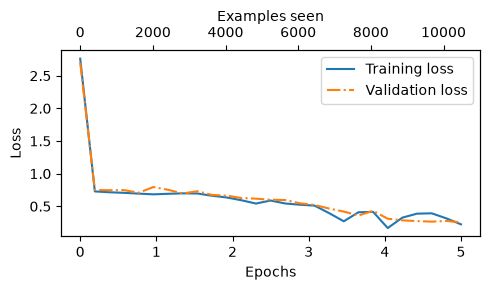

In [44]:
epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
examples_seen_tensor = torch.linspace(0, examples_seen, len(train_losses))

plot_values(epochs_tensor, examples_seen_tensor, train_losses, val_losses)

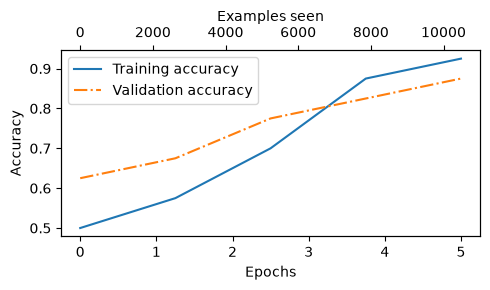

In [45]:
epochs_tensor = torch.linspace(0, num_epochs, len(train_accs))
examples_seen_tensor = torch.linspace(0, examples_seen, len(train_accs))

plot_values(epochs_tensor, examples_seen_tensor, train_accs, val_accs, label="accuracy")

In [46]:
training_accuracy = classification_accuracy(training_loader, model, device)
validation_accuracy = classification_accuracy(validation_loader, model, device)
test_accuracy = classification_accuracy(test_loader, model, device)

print(f"Training accuracy: {training_accuracy*100:.2f}%")
print(f"Validation accuracy: {validation_accuracy*100:.2f}%")
print(f"Test accuracy: {test_accuracy*100:.2f}%")

Training accuracy: 91.27%
Validation accuracy: 90.00%
Test accuracy: 90.17%


In [47]:
import re

file_name = f"{re.sub(r'[ ()]', '', CHOOSE_MODEL) }{TUNE_TRF_BLOCKS}trf-sft-class.pth"
torch.save(model.state_dict(), file_name)
print(f"Model saved as {file_name}")

# Load model via
# model.load_state_dict(torch.load("gpt2-medium355M-1trf-sft-class.pth.pth"))

Model saved as gpt2-small-124M-1trf-sft-class.pth


### 7. Using the LLM as a sentiment classifier

In [48]:
def classify_sentiment(text, model, tokenizer, device, max_length=None, pad_token_id=50256):
    model.eval()

    # Prepare inputs to the model
    input_ids = tokenizer.encode(text)
    supported_context_length = model.pos_emb.weight.shape[0]
    # Note: In the book, this was originally written as pos_emb.weight.shape[1] by mistake
    # It didn't break the code but would have caused unnecessary truncation (to 768 instead of 1024)

    # Truncate sequences if they too long
    input_ids = input_ids[:min(max_length, supported_context_length)]
    assert max_length is not None, (
        "max_length must be specified. If you want to use the full model context, "
        "pass max_length=model.pos_emb.weight.shape[0]."
    )
    assert max_length <= supported_context_length, (
        f"max_length ({max_length}) exceeds model's supported context length ({supported_context_length})."
    )    
    # Alternatively, a more robust version is the following one, which handles the max_length=None case better
    # max_len = min(max_length,supported_context_length) if max_length else supported_context_length
    # input_ids = input_ids[:max_len]
    
    # Pad sequences to the longest sequence
    input_ids += [pad_token_id] * (max_length - len(input_ids))
    input_tensor = torch.tensor(input_ids, device=device).unsqueeze(0) # add batch dimension

    # Model inference
    with torch.no_grad():
        logits = model(input_tensor)[:, -1, :]  # Logits of the last output token
    predicted_label = torch.argmax(logits, dim=-1).item()
    print("Predicted label: ", predicted_label)

    # Return the classified result
    return "positive" if predicted_label == 1 else "negative"

In [49]:
sample_1 = (
    "Unfortunately, we have to end this here."
)

print(classify_sentiment(
    sample_1, model, tokenizer, device, max_length=training_ds.max_length
))

Predicted label:  0
negative


In [50]:
sample_2 = (
    "This is awesome. We made it."
)

print(classify_sentiment(
    sample_2, model, tokenizer, device, max_length=training_ds.max_length
))

Predicted label:  1
positive


In [51]:
sample_3 = (
    "Let us make this a great effort."
)

print(classify_sentiment(
    sample_3, model, tokenizer, device, max_length=training_ds.max_length
))

Predicted label:  1
positive
